# Project 1 - Graph Search

refer to the project write up [here](https://rutgers.app.box.com/s/nmmj14j4g70nbltswcq8ooeqde3okp5x)

### The Ship

 - This is represented with an nxn grid of closed cells
 - Choose a random interior square to 'open'
 - neighbors of a cell are 1 unit away in cardinal directions
 - Iteratively: open up the ship, following protocol described in writeup
 - Identify dead ends -> for half of them pick a closed neighbor and open it

### Our Implementation:
 - We're using a numpy n x n matrix to represent the grid, and we show it using matplotlib
 - We use numerical encodings to represent different states of a cell. 1 -> closed, 0 -> open


In [84]:
import numpy as np
import matplotlib.pyplot as plt
import random
import time

In [85]:
matr = np.random.randn(3,3)

for ind, cell in np.ndenumerate(matr):
    print(f'Index: {ind}, cell: {cell}')

Index: (0, 0), cell: -1.3839748734402717
Index: (0, 1), cell: -0.034463813904393195
Index: (0, 2), cell: 1.1984764998161033
Index: (1, 0), cell: 0.40962092322185056
Index: (1, 1), cell: 0.7143201608849504
Index: (1, 2), cell: -1.350249912433944
Index: (2, 0), cell: -1.1258366193012148
Index: (2, 1), cell: 1.0316895841466285
Index: (2, 2), cell: 1.1366914215556627


In [86]:
# #Make nxn grid using numpy matrix. 1 -> closed, 0 -> open
# def CreateShip(n):
#     ship = np.ones((n,n), dtype = float)

#     #Pick random cell to open
#     x_rand, y_rand = random.randint(0, ship.shape[0]-1) , random.randint(0, ship.shape[1]-1)
#     ship[x_rand][y_rand] = 0

#     return ship


# def checkNeighbors(ship, currInd): #We call this on a closed cell to see if it has exactly 1 open neighbor, returns a boolean
#     up = (currInd[0]-1, currInd[1])
#     down = (currInd[0]+1, currInd[1])
#     left = (currInd[0], currInd[1]-1)
#     right = (currInd[0], currInd[1]+1)

#     dir = [up, down, left, right]
#     while k in range(len(dir)):
#         i,j = dir[k] #unpack coordinate tuple
#         if i < 0 or i > ship.shape[0]-1 or j < 0 or j > ship.shape[0]-1:
#             del dir[k] #delete a direction if its out of bounds
#     numOpen = 0
#     for direction in dir:
#         if ship[direction[0]][direction[1]] == 0:
#             numOpen+=1
#     if numOpen == 1:
#         return True
#     return False

# def getBlocked(ship): #Helper method that returns a list of closed cells with exactly one neighbor
#     blocked = [] #Will hold tuples of indices of blocked cells with exactly 1 open neighbor
#     for index, cell in np.ndenumerate(ship):
#         if cell == 1:
#             if checkNeigbors(ship, index): blocked.append(index) #add to blocked if checkNeighbors is true
#     return blocked
        


# def ShowShip(ship):
#     plt.imshow(ship, cmap = 'binary', interpolation = None)

#     #Ensure shows plot with increments of 1
#     plt.xticks(np.arange(-0.5, ship.shape[1], 1), labels=[])
#     plt.yticks(np.arange(-0.5, ship.shape[0], 1), labels=[])

#     #Show gridlines
#     plt.grid(True)

#     #Show colorbar
#     plt.colorbar()
#     plt.show()

# ship = CreateShip(8)
# ShowShip(ship)

In [87]:
# Let's package this all into a class
class ship:
    def __init__(self,data, open = set(), fire = set(), button = (), bot = (), closed = [()]):
        self.data = data # this should be numpy matrix
        self.open = open # set of tuples, each tuple has indices of open cell
        self.fire = fire # set of tuples, each tuple has indices of fire cell
        self.button = button #tuple
        self.bot = bot # tuple
        self.closed = closed # list of tuples

    @classmethod
    def CreateShip(cls,n):
        ship = cls(np.ones((n,n), dtype = float))
        #Pick random cell in interior to open
        x_rand, y_rand = random.randint(1, ship.data.shape[0]-2) , random.randint(1, ship.data.shape[1]-2)
        ship.data[x_rand][y_rand] = 0
        ship.open = {(x_rand, y_rand)} # We use {} to make a set, now we don't have to worry about any duplicates
        return ship

    def ShowShip(self):
        plt.imshow(self.data, cmap = 'Set1', interpolation = None)
        

        #Ensure shows plot with increments of 1
        plt.xticks(np.arange(-0.5, self.data.shape[1], 1), labels=[])
        plt.yticks(np.arange(-0.5, self.data.shape[0], 1), labels=[])

        #Show gridlines
        plt.grid(True)

        #Show colorbar
        plt.colorbar()
        plt.show()

    #Helper method that takes in indices and returns list of tuples that is 4 cardinal neighbors
    @staticmethod
    def getNeighbors(ind):
        up = (ind[0]-1, ind[1])
        down = (ind[0]+1, ind[1])
        left = (ind[0], ind[1]-1)
        right = (ind[0], ind[1]+1)
        return [up, down, left, right]
    
    
    #Helper method that takes in indices and returns list of tuples that is 4 cardinal neighbors (added try except handling for cleaner error handling)
    @staticmethod
    def getAdj(self, ind):
        try:
            up = (ind[0]-1, ind[1])
            if up in self.closed or up in self.fire:  
                up = None
        except IndexError:
            up = None
        try:
            down = (ind[0]+1, ind[1])
            if down in self.closed or down in self.fire:  
                down = None
        except IndexError:
            down = None
        try:
            left = (ind[0], ind[1]-1)
            if left in self.closed or left in self.fire:  
                left = None
        except IndexError:
            left = None
        try:
            right = (ind[0], ind[1]+1)
            if right in self.closed or right in self.fire:  
                right = None
        except IndexError:
            right = None
        coors = [up, down, left, right]
        for i in coors:
            if i == None:
                coors.remove(i)
        return coors

    # Helper to see if indices are within upper and lower bounds
    @staticmethod
    def checkBounds(upper, lower, ind):
        for i in ind:
            if i > upper or i < lower:
                return False
        return True
    
    #Helper method that takes a list of directions and ensures they're w/in bounds
    def getInbounds(self, dir):
        k = 0
        while k in range(len(dir)):
            if not ship.checkBounds(self.data.shape[0]-1, 0, dir[k]):
                del dir[k]
            else:
                k+=1
        return dir
        

    # Helper method, takes in an open cell and returns list of closed neighbors
    def checkNeighborsOpen(self, openInd):
        neighbors = ship.getNeighbors(openInd)
        valid,k = self.getInbounds(neighbors),0
        while k in range(len(valid)):
            r, c = valid[k] #unpack tuple
            if self.data[r][c] != 1:
                del valid[k]
            else:
                k+=1
        return valid
        
    #Takes in index which is a tuple that represents a cell. Checks to see if it has exactly one open neighbor
    def checkNeighborsClosed(self, Ind):
        neighbors = ship.getNeighbors(Ind)
        valid = self.getInbounds(neighbors)
        numOpen = 0
        for direction in valid:
            i,j = direction
            if self.data[i][j] == 0:
                numOpen+=1
        if numOpen == 1:return True
        return False

    #returns a list of open cells with exactly one open neighbor
    def getDeadEnds(self):
        dead_ends = []
        for openInd in self.open:
            if self.checkNeighborsClosed(openInd):
                dead_ends.append(openInd)
        return dead_ends

    def openDeadEnds(self):
        dead_ends = self.getDeadEnds()
        for i in range(len(dead_ends)//2): # Want to open ~half the dead ends
            valid_neighbors = self.getInbounds(ship.getNeighbors(dead_ends[i]))
            closed_neighbors = []
            for neighbor in valid_neighbors:
                i,j = neighbor
                if self.data[i][j] == 1:
                    closed_neighbors.append(neighbor)

            #Now we have closed neighbors of dead end, choose one at random and open
            ri = None
            if len(closed_neighbors)-1 > 0:
                ri = random.randint(0, len(closed_neighbors)-1)
                rx, ry = closed_neighbors[ri]
                self.data[rx][ry] = 0

    # In order to more efficiently open the ship we only check the blocked cells that are next to open cells
    # Then we can see which of those blocked cells has exactly 1 open neighbor.
    # While this set is not empty, we choose a random elt in the set to open
    def OpenShip(self):
        while True:
            possibly_valid_blocked, valid_blocked = [],[]
            for open in self.open:
                possibly_valid_blocked += self.checkNeighborsOpen(open)
            for possibly_valid in possibly_valid_blocked:
                if self.checkNeighborsClosed(possibly_valid): valid_blocked.append(possibly_valid)
            if len(valid_blocked) != 0:
                #choose random valid blocked and open it
                ri = random.randint(0, len(valid_blocked)-1)
                i, j = valid_blocked[ri]
                self.data[i][j] = 0 # Open randomly chosen cell
                self.open.add((i,j)) # Add this to set of open cells
            else:
                break
    

    def chooseInitSpawns(self):
        coor = []
        nums = set()
        openCoors = list(self.open)
        while len(coor) < 3: # loop for 3 distinct coordinates to set our bot, button, and fire
            randCoorInd = random.randint(0, len(openCoors))
            if randCoorInd not in nums: # make sure coordinates picked are distinct 
                coor.append(openCoors[randCoorInd])
            nums.add(randCoorInd) 
        self.fire.add(coor[0]) # set class level fields to starting coordinates (done randomly)
        self.bot = coor[1]
        self.button = coor[2]
        for i in coor:
            self.data[i[0]][i[1]] = 2 # ship color updated to add new points 
        
    def flammability(self, probabilty):
        a = 1 - probabilty
        q = a ** len(self.fire) #(nneeds to be neightbors not just cur fire cells)
        return 1 - q
    
    def spreadFire(self, probability):
        fireNeighbors = {}
        for fireCoor in self.fire: # should i use hashmap or not is it adding anything to the function?
            fireNeighbors[fireCoor] = self.getAdj(fireCoor)
        neighbors = []
        for n in fireNeighbors.values():
            neighbors.append(n)
        for eachCoor in neighbors:
            prob = self.flammability(probability)
            if prob >= 0.5:
                self.fire.append(eachCoor)
        # call function that changes color of all new fire cells on the ship and updates self.fire
    #     # check open neighbors of each fire cell (thinking we put them in hashmap so its ==> (fire coor -> all open spreadable neighbors))
    #     # based on flammability function if random value between 0 - 1 is within flammability then choose one fire coor for one step to spread to one neighbor 
    #     # update self.fire with new fire cells if any

    def checkBotInFire(self):
        for coor in self.fire:
            if coor == self.bot:
                return True
        return False
    
    def events(self):
        time = 0
        while(True):
            self.checkBotInFire()
            # bot moves
            # fire updates
            self.spreadFire()
            # time updates
            time += 1
            

    

    



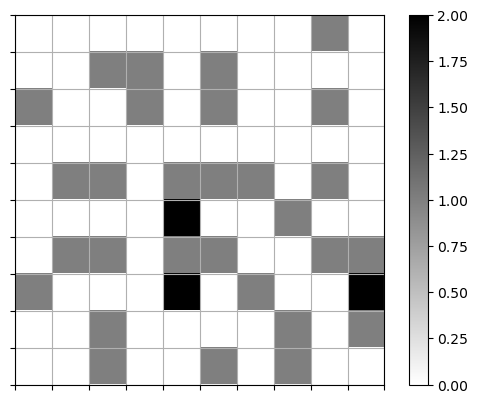

In [88]:
space_ship = ship.CreateShip(10)
space_ship.OpenShip()
space_ship.openDeadEnds()
space_ship.chooseInitSpawns()
space_ship.ShowShip()